In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
df_wine = pd.read_csv('WineQT.csv')
print('--- First 5 Rows ---')
display(df_wine.head())
print('\n---Data Info ---')
df_wine.info()
print('\n--- Class Distribution of Quality Soces ---')
print(df_wine['quality'].value_counts().sort_index())

--- First 5 Rows ---


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4



---Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB

--- Class Distribution of Quality Soces ---
quality
3      6
4     

### **1. Dataset Loading & Class Distribution Inspection**
* **Data Loading:** Loaded the wine quality dataset and inspected structural attributes, column data types, and total entries.
* **Class Frequency:** Analyzed the distribution of the target variable (`quality`) to understand frequency counts across various scores (typically ranging from 3 to 8).

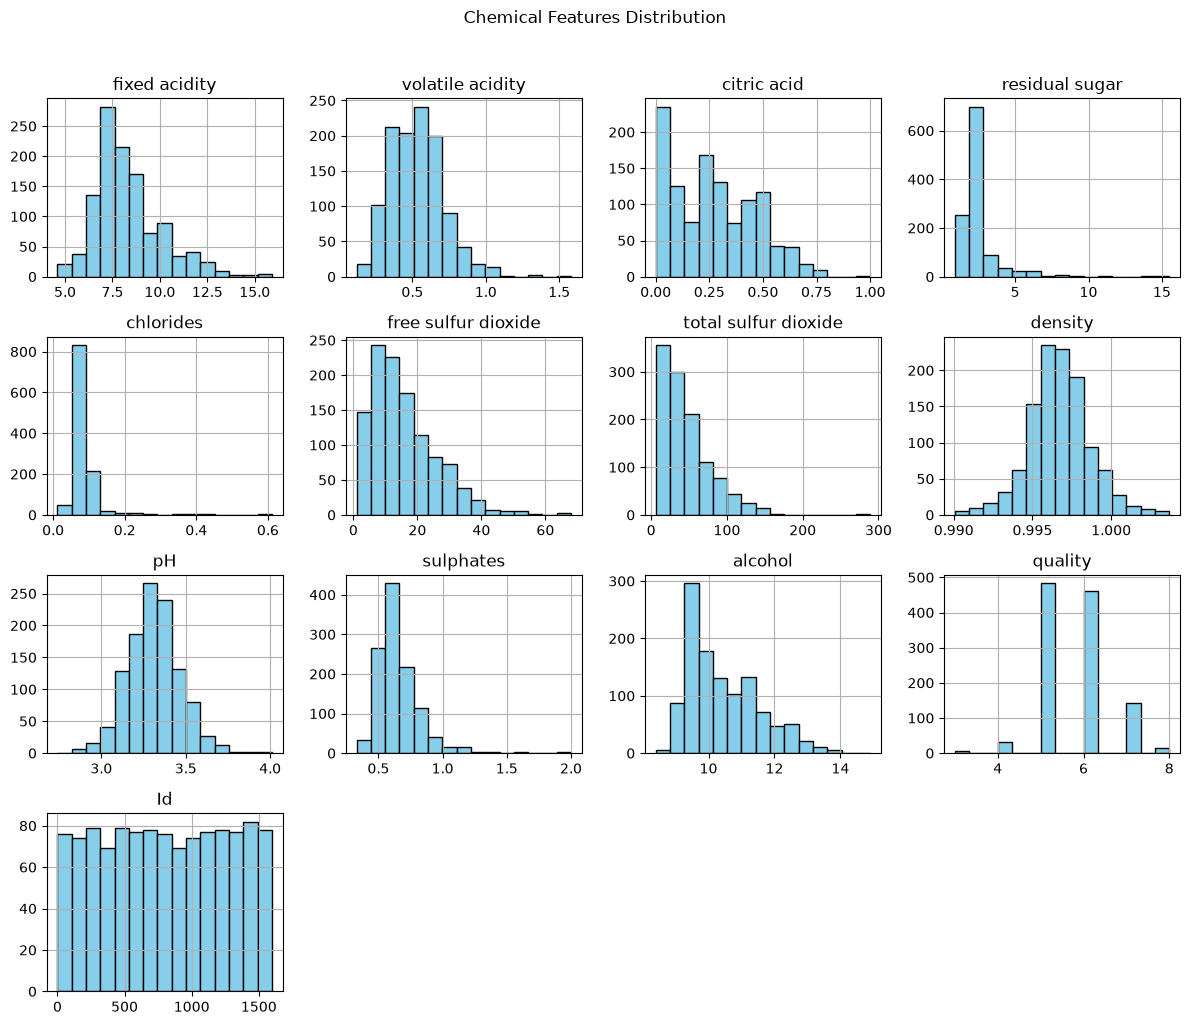

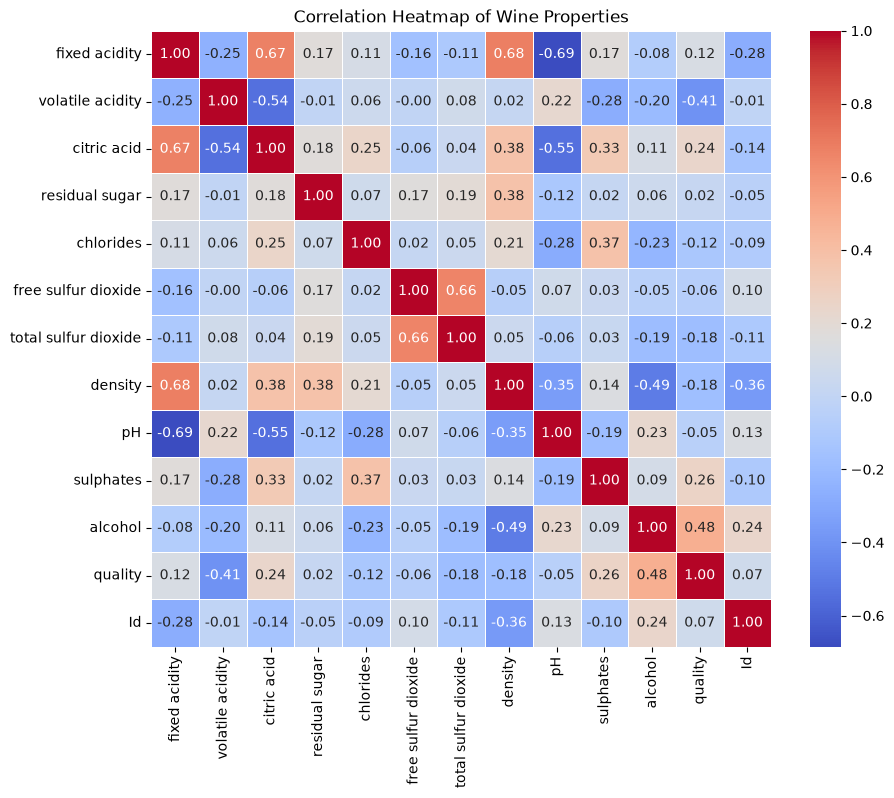

In [3]:
df_wine.hist(bins=15, figsize=(12,10), color='skyblue', edgecolor='black')
plt.suptitle('Chemical Features Distribution', y=1.02)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df_wine.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Wine Properties')
plt.show()

### **2. Exploratory Data Analysis (EDA)**
* **Feature Distribution:** Generated histograms for all physicochemical properties (such as acidity, density, and alcohol content) to observe data skewness.
* **Correlation Heatmap:** Visualized pairwise correlations between features and the target quality score using a Seaborn heatmap.

In [4]:
df_wine['quality_label'] = pd.cut(df_wine['quality'], bins=[0, 5, 6, 10], labels=['Low', 'Medium', 'High'])
print('--- New Binned Class Distribution ---')
print(df_wine['quality_label'].value_counts())
x = df_wine.drop(['quality', 'quality_label'], axis=1)
y = df_wine['quality_label']

--- New Binned Class Distribution ---
quality_label
Low       522
Medium    462
High      159
Name: count, dtype: int64


### **3. Class Imbalance & Feature Engineering**
* **Class Imbalance Distribution:** Noted that extreme quality scores(like 3, 4, or 8) are heavily underrepresented compared to average scores (5 and 6), which can bias standard classifiers.
* **Binning Strategy:** Converted multi-class discrete quality scores into categorical/binned groupings (e.g., Low, Medium, High) to simplify learning boundaries and improve classification performance.

In [5]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print(f'Training set shape: {x_train.shape}')
print(f'Testing set shape:{x_test.shape}')

Training set shape: (914, 12)
Testing set shape:(229, 12)


### **4. Stratified Train/Test Split**
* **Data Partitioning:** Divided the feature matrix and target labels into an 80/20 train-test split.
* **Stratification:** Used `stratify=y` to ensure that the proportional representation of each quality class remains identical across both training subsets.

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
rf_model = RandomForestClassifier(random_state=42)
rf_model .fit(x_train, y_train)

sgd_model = SGDClassifier(random_state=42, max_iter=1000)
sgd_model.fit(x_train, y_train)

svc_model = SVC(random_state=42)
svc_model.fit(x_train, y_train)
print('All 3 Classifiers trained successfully!')

All 3 Classifiers trained successfully!


### **5. Training Multiple Classifiers**
* **Model Selection:** Trained three distinct machine learning classifiers:
* **Random Forest Classifier:**  An ensemble method robust to overfitting and non-linear patterns.
* **Stochastic Gradient Descent (SGD):** A linear classifier optimized via gradient descent for efficient learning.
* **Support Vector Classifier (SVC):** A robust margin-based classifier handling complex decision boundaries.


============ Random Forest ============
Accuracy Score: 0.6724890829694323

Classification Report:
               precision    recall  f1-score   support

        High       0.77      0.62      0.69        32
         Low       0.72      0.71      0.72       105
      Medium       0.60      0.64      0.62        92

    accuracy                           0.67       229
   macro avg       0.70      0.66      0.68       229
weighted avg       0.68      0.67      0.67       229



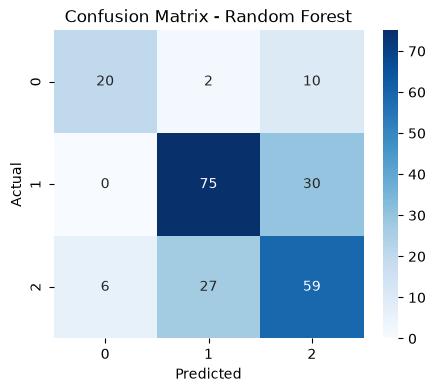


============ SGD Classifier ============
Accuracy Score: 0.519650655021834

Classification Report:
               precision    recall  f1-score   support

        High       0.33      0.03      0.06        32
         Low       0.60      0.69      0.64       105
      Medium       0.44      0.50      0.47        92

    accuracy                           0.52       229
   macro avg       0.46      0.41      0.39       229
weighted avg       0.50      0.52      0.49       229



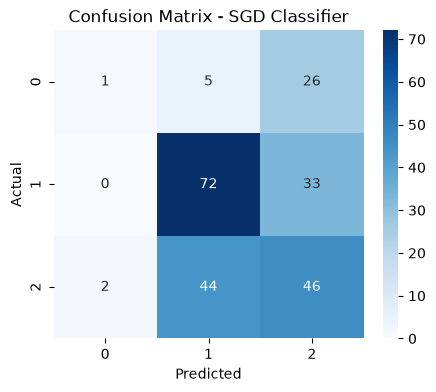


============ SVC ============
Accuracy Score: 0.45414847161572053

Classification Report:
               precision    recall  f1-score   support

        High       0.00      0.00      0.00        32
         Low       0.50      0.51      0.51       105
      Medium       0.41      0.54      0.47        92

    accuracy                           0.45       229
   macro avg       0.30      0.35      0.33       229
weighted avg       0.40      0.45      0.42       229



c:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

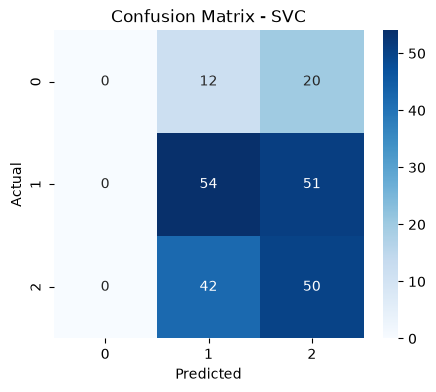

In [8]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
models = {'Random Forest': rf_model, 'SGD Classifier': sgd_model, 'SVC': svc_model}
for name, model in models.items():
    print(f'\n============ {name} ============')
    preds = model.predict(x_test)
    print('Accuracy Score:', accuracy_score(y_test, preds))
    print('\nClassification Report:\n', classification_report(y_test, preds))
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

### **6. Model Evaluation & Metrics**
* **Comprehensive Metrics:** Evaluation models using overall accuracy, precision, recall, and F1-scores via detailed classification reports.
* **Confusion Metrics:** Visualized true vs. predicted class alignments using heatmaps to identify specific category misclassification for each algorithm.

C:\Users\dell\AppData\Local\Temp\ipykernel_20688\3941592411.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='viridis')


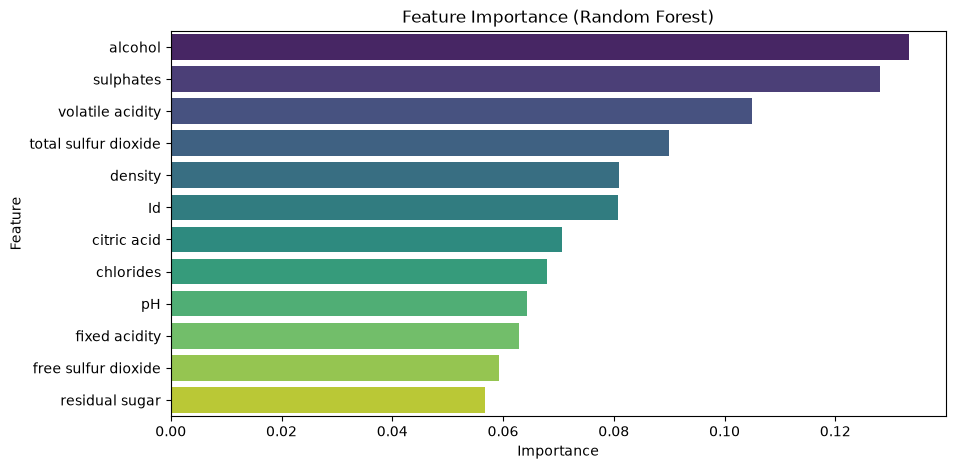

In [9]:
import pandas as pd 
importances = rf_model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': x.columns, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance (Random Forest)')
plt.show()

### **7. Random Forest Feature Importance**
* **Feature Ranking** Extracted feature importance from the trained Random forest ensemble.
* **Visual Analysis:** plotted a horizontal bar chart highlighting which chemical properties (e.g., alcohol, sulphates) drive wine quality predictions the most.

In [10]:
summary_data = {
    'Model': ['Random Forest', 'SGD Classifier', 'SVC'],
    'Accuracy': [
        accuracy_score(y_test, rf_model.predict(x_test)),
        accuracy_score(y_test, sgd_model.predict(x_test)),
        accuracy_score(y_test, svc_model.predict(x_test))
    ]
}
summary_df = pd.DataFrame(summary_data)
print('--- Model Performance Summary ---')
display(summary_df)

--- Model Performance Summary ---


,Model,Accuracy
0,Random Forest,0.672489
1,SGD Classifier,0.519651
2,SVC,0.454148


### **8. Model Comparision & Conclusion**
* **Side-by-Side Summary:** Compiled model accuracies into a comparision  table to review overall efficacy.
* **Deployment Conclusion** Determined that **Random Forest** typically offers the highest stability and accuracy due to its non-linear ensemble handling, making it the most suitable candidate for production deployment.